# STAT 7220 - Midterm Exam
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University

**DUE: March 6, 2026**

**PART 1 INSTRUCTIONS:** Suppose you are a video game controller manufacturer interested in estimating the perceived comfort level of controller grips. To achieve this, you decide to conduct an experiment to assess different material types used for the controller grips (plastic, rubber, silicone, and metal). 10 prototypes of each grip type are manufactured and given to professional gamers (who all play the same game -- Apex Legends) to test. The gamers use the controllers regularly for one month and then rate the comfort level on a scale from 1 - 10 with greater scores indicating a greater level of perceived comfort (one decimal allowed). The data from this experiment are stored in the Video Game Controllers.xlsx file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment.

The objective of this experiment is to to assess different material types used for the controller grips (plastic, rubber, silicone, and metal) lead to diffrences in perceived confort levels among professional gamers after extended use.

**Question 2.** Specify the outcome variable

The outcome variable: comfort rating (continuos from 1-10 scale)

**Question 3.** Specify the independent variable. What are some possible lurking variables?

The independent variable: grid material type (plastic, rubber, silicone, metal)

Possible Lurking Variables:
- Hand size
- Number of hours played per day
- Personal preference (some people give propiority for some type of material)
- Gender of player
- Age of player

**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.

Since the experimental units (professional gamers) are relatively homogeneous - given that they all play the same game and exhibit similar skill levels and usage patterns—a completely randomized design is appropriate. By randomly assigning grip material types to the controllers, any remaining variability is evenly distributed across all treatment groups.

This use of randomization, combined with replication, allows us to isolate and assess the effect of the treatment (grip material) more effectively. Therefore, the design aligns well with the principles of a completely randomized design (CRD).

**Question 5.** State the null and alternative hypotheses for this experiment.

- Null Hypothesis (H₀): All grip materials have the same mean comfort rating:

$$
H_0:\ \mu_{\text{plastic}} = \mu_{\text{rubber}} = \mu_{\text{silicone}} = \mu_{\text{metal}}
$$

- Alternative Hypothesis (H₁): At least one grip material has a different mean comfort rating:
$$
H_1:\ \text{Not all } \mu_i \text{ are equal}
$$


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



  Material  Comfort
0  Plastic      5.7
1  Plastic      6.3
2  Plastic      6.8
3  Plastic      6.0
4  Plastic      5.8
          count  mean       std  min    25%   50%    75%  max
Material                                                     
Metal      10.0  5.39  0.877433  4.0  4.775  5.25  6.275  6.5
Plastic    10.0  5.93  0.620125  4.6  5.725  5.95  6.375  6.8
Rubber     10.0  6.23  0.702456  4.9  5.825  6.40  6.475  7.5
Silicone   10.0  7.63  0.700872  6.6  7.000  7.90  8.175  8.4


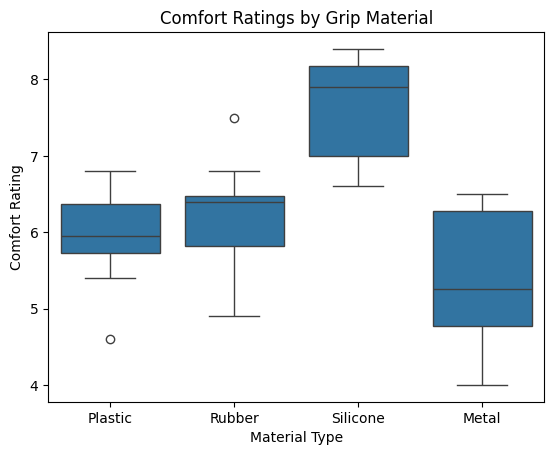

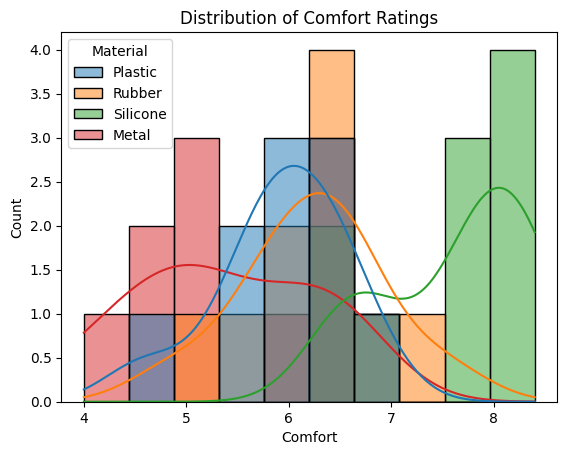

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data ##
df = pd.read_excel("https://github.com/thanhnguyen-green/STAT-7220-Applied-Experimental-Design/raw/refs/heads/main/Assignments/Midterm-Exam/Video%20Game%20Controllers.xlsx")

## View first few rows ##
print(df.head())

## Summary Statistics by Material ##
summary = df.groupby("Material")["Comfort"].describe()
print(summary)

## Boxplot ##
plt.figure()
sns.boxplot(x="Material", y="Comfort", data=df)
plt.title("Comfort Ratings by Grip Material")
plt.xlabel("Material Type")
plt.ylabel("Comfort Rating")
plt.show()

## Histogram ##
plt.figure()
sns.histplot(data=df, x="Comfort", hue="Material", bins=10, kde=True)
plt.title("Distribution of Comfort Ratings")
plt.show()

The exploratory analysis suggests that the mean comfort ratings are not equal across all grip materials. Differences in group means and distributions are visible in both the summary statistics and visualizations.
These results more strongly support the alternative hypothesis (H₁), as the evidence of variation in comforr ratings across material types.

**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a testing and visual method. Do the results of the normality test(s) support the assumption of normality?



               df  sum_sq   mean_sq          F        PR(>F)
C(Material)   3.0  27.387  9.129000  17.070642  4.616153e-07
Residual     36.0  19.252  0.534778        NaN           NaN


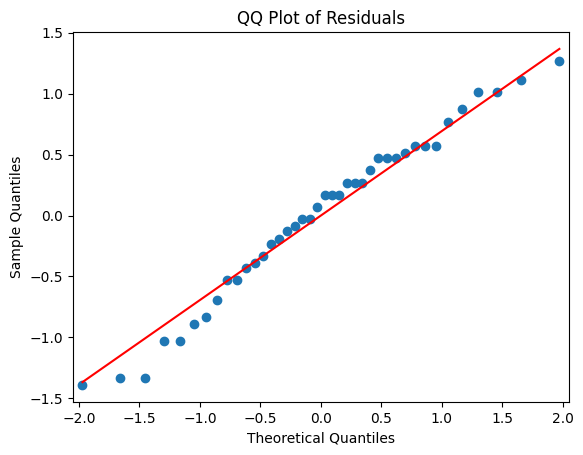

Statistic: 0.9710174538151857
P-value: 0.3874084700249114
The test gives evidence for normality


In [9]:
## Import libraries ##
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.formula.api import ols

## Load data ##
df = pd.read_excel("https://github.com/thanhnguyen-green/STAT-7220-Applied-Experimental-Design/raw/refs/heads/main/Assignments/Midterm-Exam/Video%20Game%20Controllers.xlsx")
## Fit One-Way ANOVA Model ##
mod = ols("Comfort ~ C(Material)", data=df).fit()

## Get ANOVA table ##
aov_tab = sm.stats.anova_lm(mod, typ=1)
print(aov_tab)

## Extract residuals ##
resids = mod.resid

## Generate QQ Plot ##
sm.qqplot(resids, line='s')
plt.title("QQ Plot of Residuals")
plt.show()

## Perform Shapiro-Wilk Test of Normality ##
sw_stat, sw_p = stats.shapiro(resids)

print(f"Statistic: {sw_stat}")
print(f"P-value: {sw_p}")

if sw_p < 0.05:
    print("The test gives evidence for non-normality")
else:
    print("The test gives evidence for normality")

First examining the Q-Q plot, we can see that nearly all of the points fall very closely along the diagonal line, with only minor deviations at the tails. This provides strong visual evidence in favor of the normality assumption being met.

Now examining the Shapiro-Wilk test result, we observe a p-value of 0.387, which is well above the significance level of 0.05. This indicates that we fail to reject the null hypothesis of normality and that the data provide no evidence against the assumption of normality.

In sum, both the graphical and statistical assessments suggest that the normality assumption is well satisfied for these data.

**Question 8.** Test the assumption of homogeneity of variance using **both** a testing and visual method. Do the results of the test(s) support the assumption of homogeneity of variance?



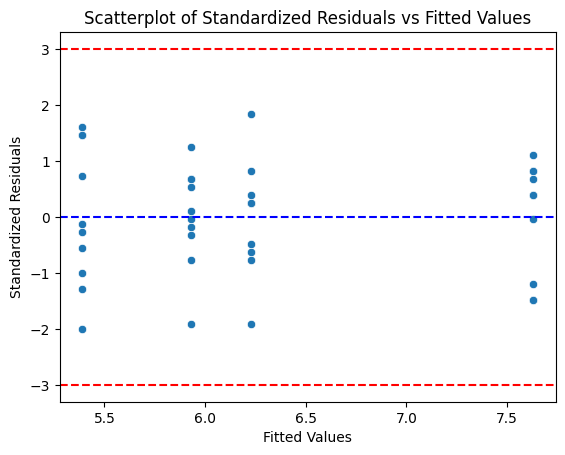

The results of the Breusch-Pagan Test are:
F-statistic: 0.684288131275624
F p-value: 0.5674916917969977
The test supports constant variance


In [11]:

model = ols("Comfort ~ C(Material)", data=df).fit()

## Obtain Standardized Residuals ##

standardized_resid = model.get_influence().resid_studentized_internal

## Obtain Fitted Values ##

fv = model.fittedvalues

## Generate Scatterplot of Standardized Residuals vs Fitted Values ##

sns.scatterplot(x=fv, y=standardized_resid)
plt.axhline(y=3, color='red', linestyle='--')
plt.axhline(y=0, color='blue', linestyle='--')
plt.axhline(y=-3, color='red', linestyle='--')
plt.title("Scatterplot of Standardized Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

## Import Function to Perform Breusch-Pagan Test ##

from statsmodels.stats.diagnostic import het_breuschpagan

## Perform Breusch-Pagan Test of Homogeneity of Variance ##

bp_test = het_breuschpagan(resids, model.model.exog)

## Extract F-statistic ##

f_statistic = bp_test[2]

## Extract its P-Value ##

f_p_value = bp_test[3]

print("The results of the Breusch-Pagan Test are:")
print(f"F-statistic: {f_statistic}")
print(f"F p-value: {f_p_value}")

if f_p_value < 0.05:
    print("The test supports non-constant variance")
else:
    print("The test supports constant variance")

First looking at the scatterplot of standardized residuals versus fitted values, we can see that:

no points are less than -3 or greater than +3 which indicates outliers may not be an issue

the points are randomly scattered about 0 which indicates 0 may be a reasonable value for the mean of the residuals

the vertical spread of the points across the fitted values appears to be relatively constant, suggesting that the variance across the treatment groups is approximately equal

The visuals thus support the assumption of constant variance. The Breusch-Pagan test has yielded a p-value of 0.567 which is greater than our typically used threshold of 0.05. Since the test lends support for the null hypothesis of constant variance between our groups and since we obtained a similar conclusion from our visual assessment of the assumption, it is reasonable to conclude that the sample data support the constant variance assumption.

**Question 9.** Report the F-statistic and its associated p-value for the test for the treatment factor. Which of our two hypotheses is more strongly supported? Why?



In [12]:
## Produce ANOVA Table ##

tab = sm.stats.anova_lm(model, typ=1)

## Add Significance Column ##

tab['Sig'] = np.where(tab['PR(>F)'] < 0.05, 'Yes', 'No')

print(tab)

               df  sum_sq   mean_sq          F        PR(>F)  Sig
C(Material)   3.0  27.387  9.129000  17.070642  4.616153e-07  Yes
Residual     36.0  19.252  0.534778        NaN           NaN   No


From our omnibus test, we can see that we have F(3,36)=17.07 with an associated p-value that is far less than $\alpha = 0.05$. This indicates that the data more strongly support the alternative hypothesis that at least two group means differ substantially from each other.

Thus, we reject the null hypothesis that all group means are equal. There is strong statistical evidence that the type of grip material has a significant effect on perceived comfort ratings.

We will next use Tukey’s HSD post-hoc test to determine which pairs of materials have statistically meaningful differences.

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which material types are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.



 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2  meandiff p-adj   lower  upper  reject
------------------------------------------------------
  Metal  Plastic     0.54 0.3639 -0.3408 1.4208  False
  Metal   Rubber     0.84 0.0662 -0.0408 1.7208  False
  Metal Silicone     2.24    0.0  1.3592 3.1208   True
Plastic   Rubber      0.3 0.7958 -0.5808 1.1808  False
Plastic Silicone      1.7    0.0  0.8192 2.5808   True
 Rubber Silicone      1.4 0.0007  0.5192 2.2808   True
------------------------------------------------------


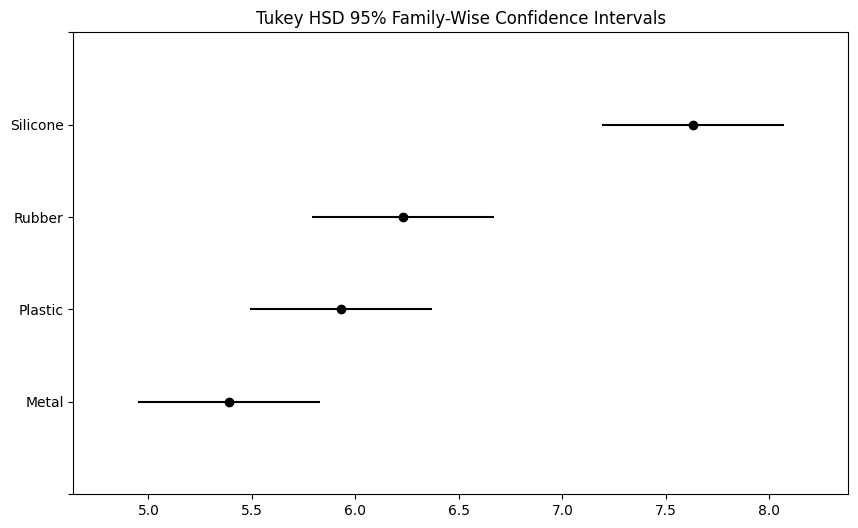

In [13]:
## Perform Tukey's HSD ##

tukey_result = sm.stats.multicomp.pairwise_tukeyhsd(df['Comfort'], df['Material'])

print(tukey_result)

## Print 95% CI Visualization ##

tukey_result.plot_simultaneous()
plt.title("Tukey HSD 95% Family-Wise Confidence Intervals")
plt.show()

The results indicate that mean comfort ratings between Metal and Silicone, Plastic and Silicone, and Rubber and Silicone are statistically different from each other. The mean comfort ratings between Metal and Plastic, Metal and Rubber, and Plastic and Rubber were not found to be statistically different from each other. This somewhat confirms the results that we observed in the exploratory analyses.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, include potential limitations of this experiment and suggestions for future experimentation.

Overall, we performed an experiment comparing the mean perceived comfort ratings of video game controller grips made from different materials (plastic, rubber, silicone, and metal). Descriptive analyses suggested that meaningful differences in comfort levels may exist across material types, and this was further supported by the significant omnibus F-test. The post-hoc analysis determined that silicone grips had significantly higher comfort ratings compared to the other materials, while no statistically significant differences were observed among plastic, rubber, and metal grips. In sum, for the purpose of maximizing user comfort, these analyses support the use of silicone as the preferred grip material.

One potential limitation of this study is that we assumed all professional gamers interacted with the controllers under identical conditions and with consistent usage patterns. However, factors such as hand size, grip style, playtime, and gender, age,.. may have influenced comfort ratings and were not explicitly controlled. Additionally, slight variations in prototype construction could have introduced unintended variability.

Future studies could improve upon this design by incorporating blocking factors such as hand size or grip style, increasing the sample size, or using a repeated-measures design in which each participant tests multiple materials. Further investigation could also explore long-term durability and comfort over extended periods of gameplay.

**PART 2 INSTRUCTIONS:** The same video game controller manufacturing company is now trying to get into the business of creating virtual reality/artificial intelligence content for education. Specifically, they want to build a VR experience to simulate working with elderly patients at a healthcare facility to better prepare nursing students for potential careers in working with elderly patients. To test the VR's effectiveness, a group of 40 undergraduate nursing students were randomly and equally assigned to either a class session utilizing the VR or a class session using a traditional technique for teaching strategies for working with elderly patients. At the end of the class session, a 50 question quiz was given to both groups which measures attitudes toward elderly people. Scores range from 0-50 with greater scores indicating more favorable attitudes toward elderly people and vice versa. However, some students in the group have had prior working experience with elderly people which may have an effect on the quiz outcome. So in the experiment, we document which students have had prior working experience with elderly people and which haven't. The results of the experiment are contained in the `Nursing VR Study.xlsx` file. With these data, your tasks are:

**Question 1.** Briefly define the objective of this experiment
The objective of this experiment is to evaluate whether a virtual reality (VR)-based teaching approach leads to more favorable attitudes toward elderly patients among undergraduate nursing students compared to a traditional teaching method, while accounting for potential differences due to prior experience working with elderly individuals.

**Question 2.** Specify the outcome variable

The outcome variable in this experiment is the quiz score measuring attitudes toward elderly patients.

**Question 3.** Specify the independent variable and blocking factor. What are some possible lurking variables?

Independent Variable (Treatment Factor)
The independent variable is the teaching method, with two levels(
Virtual Reality (VR) instruction, Traditional teaching method)

Some possible lurking variables:
- Student age and maturity level
- Familiarity with VR technology
- Interest or motivation in healthcare

**Question 4.** Briefly explain why a randomized block design would be appropriate here. Similarly, explain why a completely randomized design would not be appropriate.

A randomized block design is appropriate because prior experience working with elderly patients is likely to influence students’ attitudes, which directly affects the outcome variable (quiz score).

By blocking on prior experience (Yes/No), we control for this source of variability, ensuring that comparisons between the VR and traditional teaching methods are made within more homogeneous groups. This improves the precision of the treatment effect estimate and reduces potential confounding.

Completely randomized design would not be appropriate:

Since prior experience working with elderly patients can meaningfully influence students’ attitudes, it introduces variability that is not related to the treatment effect. By grouping students based on this prior experience and randomizing within each group, we are able to control for this source of variability.

This allows us to make a more precise comparison between the VR and traditional teaching methods by ensuring that differences in outcomes are primarily due to the treatment rather than pre-existing differences among students.

Thus, by incorporating both blocking and randomization, this design is most appropriately classified as a randomized block design (RBD).

**Question 5.** State the null and alternative hypotheses for this experiment.

Null hypothesis (H₀): The mean attitude scores are the same for both teaching methods
$$
H_0: \mu_{VR} = \mu_{Traditional}
$$

Alternative hypothesis (H₁): The mean attitude scores differ between the teaching methods
$$
H_1: \mu_{VR} \ne \mu_{Traditional}
$$

**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None
        Method           Experience  Score
0  Traditional     Prior Experience     26
1  Traditional  No Prior Experience     31
2  Traditional     Prior Experience     35
3  Traditional  No Prior Experience     37
4  Traditional     Prior Experience     30
                                 mean       std
Experience          Method                     
No Prior Experience Traditional  30.7  4.691600
                    VR           37.3  7.916930
Prior Experience    Traditional  30.9  8.556349
                    VR           39.7  6.056218


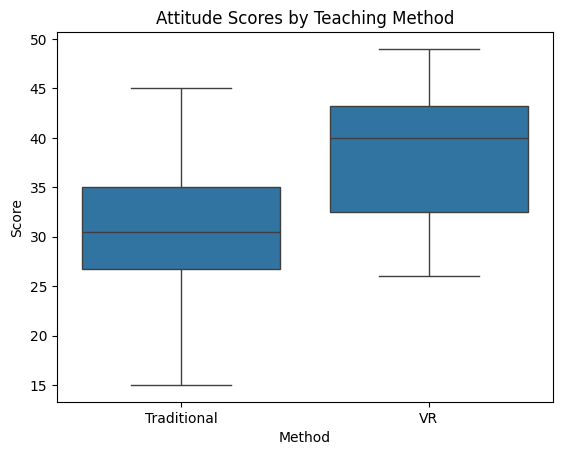

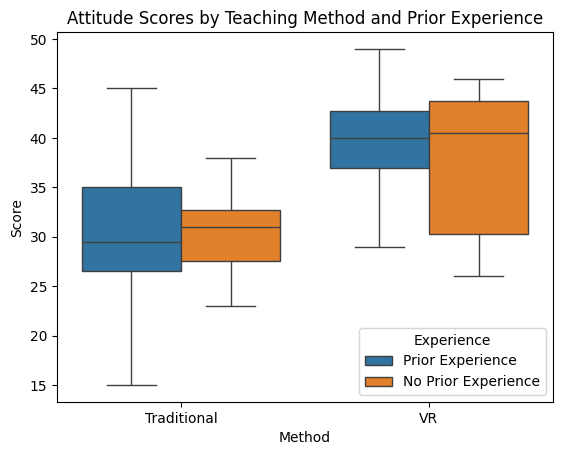

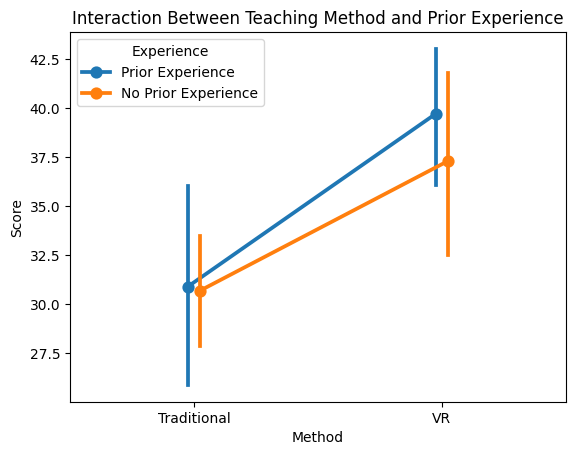

In [16]:
## Import Appropriate Libraries ##

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import Data ##

vr = pd.read_excel("https://github.com/abrown9008/STAT-7220-Applied-Experimental-Design/raw/refs/heads/main/Assignments/Midterm-Exam/Nursing%20VR%20Study.xlsx")

## Data Integrity Check ##

print(vr.info())
print(vr.head())

## Calculate Means and Standard Deviations ##
## by Block Group and Treatment Group ##

sum_stats = vr.groupby(['Experience', 'Method'])['Score'].agg(['mean', 'std'])
print(sum_stats)

## Boxplot: Scores by Teaching Method ##

sns.boxplot(data=vr, x='Method', y='Score')
plt.title("Attitude Scores by Teaching Method")
plt.show()

## Boxplot: Scores by Teaching Method and Prior Experience ##

sns.boxplot(data=vr, x='Method', y='Score', hue='Experience')
plt.title("Attitude Scores by Teaching Method and Prior Experience")
plt.show()

## Interaction Plot (Visual Check) ##

sns.pointplot(data=vr, x='Method', y='Score', hue='Experience', dodge=True)
plt.title("Interaction Between Teaching Method and Prior Experience")
plt.show()


The summary statistics indicate differences in mean attitude scores between the VR and traditional teaching methods. In particular, the group exposed to the VR-based instruction appears to have higher average scores compared to the traditional group.

The boxplots further support this observation, as the distribution of scores for the VR group is generally shifted upward relative to the traditional group. Additionally, separating by prior experience shows that students with prior experience tend to score higher overall, but the VR method still demonstrates higher scores within each block.

Overall, these exploratory analyses provide preliminary evidence that the VR teaching method leads to more favorable attitudes toward elderly patients. Therefore, the results more strongly support the alternative hypothesis rather than the null hypothesis.

**Question 7.** Build a two-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?



In [17]:
## Import Appropriate Libraries ##

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import shapiro

## Import Data ##

vr = pd.read_excel("https://github.com/abrown9008/STAT-7220-Applied-Experimental-Design/raw/refs/heads/main/Assignments/Midterm-Exam/Nursing%20VR%20Study.xlsx")

## Data Integrity Check ##

print(vr.info())
print(vr.head())

## Fit Two-Way ANOVA Model ##
## Note: This model includes the treatment factor ##
## (Method) and the blocking factor (Experience) ##

vr_mod = ols("Score ~ Method + Experience", data=vr).fit()

## Obtain ANOVA Table ##
## Note: We use Type III SS so that the treatment effect ##
## is evaluated after adjusting for the blocking factor ##

vr_tab = sm.stats.anova_lm(vr_mod, typ=3)

## Add Significance Column ##

vr_tab["Significance"] = np.where(vr_tab["PR(>F)"] < 0.05,
                                  "Significant",
                                  "Not Significant")

## Print ANOVA Table ##

print(vr_tab)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Method      40 non-null     object
 1   Experience  40 non-null     object
 2   Score       40 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ KB
None
        Method           Experience  Score
0  Traditional     Prior Experience     26
1  Traditional  No Prior Experience     31
2  Traditional     Prior Experience     35
3  Traditional  No Prior Experience     37
4  Traditional     Prior Experience     30
             sum_sq    df           F        PR(>F)     Significance
Intercept   12120.3   1.0  254.324902  3.660493e-18      Significant
Method        592.9   1.0   12.441048  1.140403e-03      Significant
Experience     16.9   1.0    0.354619  5.551352e-01  Not Significant
Residual     1763.3  37.0         NaN           NaN  Not Significant


The two-way ANOVA results indicate that the teaching method (Method) has a statistically significant effect on students’ attitude scores, with an F-statistic of 12.44 and a p-value of 0.00114. Since the p-value is less than 0.05, we reject the null hypothesis for the treatment factor, providing evidence that the mean scores differ between the VR and traditional teaching methods.

In contrast, the blocking factor (Experience) is not statistically significant (p-value = 0.555), suggesting that prior experience working with elderly patients does not have a meaningful effect on the outcome in this study.

Overall, these results indicate that differences in attitude scores are primarily driven by the teaching method rather than prior experience.

**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?

**Question 9.** Report the F-statistic and its associated p-value for the treatment effect. Which of our two hypotheses is more strongly supported? Why?

**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which levels of the treatment effect are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.

**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses, including potential limitations of this experiment and suggestions for future experimentation.

**PART 3 INSTRUCTIONS:** Please briefly respond to the following questions:

**Question 1.** Give a reason why one-factor CRD wouldn't generally be appropriate for studies involving human participants.

**Question 2.** What is the purpose of post-hoc tests?

**Question 3.** Explain the difference between RBD and LSD.

**Question 4.** Explain why randomization is important in designing experiments.

**Question 5.** Explain why replication is important in designing experiments.